In [1]:
import eos
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
from IPython.display import display, Latex
#import re
import yaml
#from tabulate import tabulate
from wquantiles import quantile
from collections import OrderedDict
from scipy import integrate
import mpmath as mp
import sympy as sp

import chi_OPE as chi

BASE_DIRECTORY='./data_base'
TEST_BASE_DIRECTORY='./test_base'
ANALYSIS_FILE='./an_file.yaml'

def weighted_mean_std(samples, weights):
    mean = np.average(samples, weights=weights)
    var = np.average((samples - mean) ** 2, weights=weights)
    return mean, np.sqrt(var)

def find_index_for_q2(prediction, obs_name, q2_value):
    candidates = []
    for idx, item in enumerate(prediction.varied_parameters):
        if item.get('name') != obs_name:
            continue
        kin = item.get('kinematics', {})
        if 'q2' in kin:
            candidates.append((idx, float(kin['q2'])))
    if not candidates:
        return None, None
    idx, q2_best = min(candidates, key=lambda t: abs(t[1] - q2_value))
    return idx, q2_best

def range_from_pred(prediction, obs_name, q2_vals, nsigma=3.0, pad_frac=0.1):
    vals = []
    for q2 in q2_vals:
        idx, _ = find_index_for_q2(prediction, obs_name, q2)
        if idx is None:
            continue
        mean, std = weighted_mean_std(prediction.samples[:, idx], prediction.weights)
        vals.extend([mean - nsigma * std, mean + nsigma * std])
    if not vals:
        return [0.0, 1.0]
    vmin, vmax = min(vals), max(vals)
    pad = (vmax - vmin) * pad_frac if vmax != vmin else max(abs(vmin) * pad_frac, 1e-4)
    return [vmin - pad, vmax + pad]

def print_params_from_posterior(base, posterior):
    posterior_dir = os.path.join(base, 'data', posterior, 'samples')

    data = eos.data.ImportanceSamples(posterior_dir)
    samples = data.samples
    weights = data.weights
    varied = [p["name"] for p in data.varied_parameters]
    for name in varied:
        idx = varied.index(name)
        mean, std = weighted_mean_std(samples[:, idx], weights)
        print(f"{name}: {mean:e} ± {std:.2e}")

def print_pred_from_posterior(base, posterior, pred_name, obs_name, q2_vals):
    pred_dir = os.path.join(base, 'data', posterior, f'pred-{pred_name}')
    data = eos.data.Prediction(pred_dir)
    samples = data.samples
    weights = data.weights

    idx_q2best = []
    for q2 in q2_vals:
        idx, q2_best = find_index_for_q2(data, obs_name, q2)
        if idx is not None:
            idx_q2best.append((idx, q2_best))
    if not idx_q2best:
        print(f"No entries found for {obs_name} in {pred_name}")
        return
    for idx, q2_best in idx_q2best:
        mean, std = weighted_mean_std(samples[:, idx], weights)
        print(f"{obs_name} at q^2={q2_best:.1f}: {mean:e} ± {std:.2e}")

$\chi_{OPE}$ is implemented in the imported ```chi_OPE.py```.
Args: subtraction point, s0 

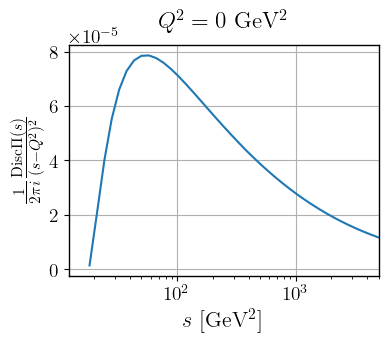

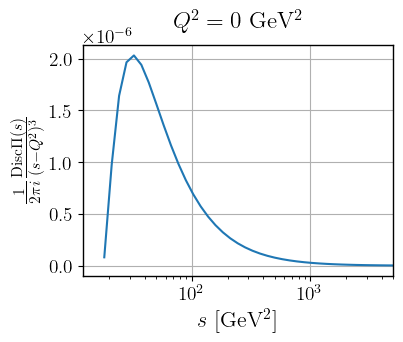

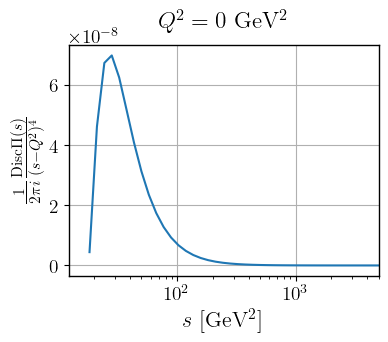

In [10]:
#Q2 = -chi.mb**2
Q2 = 0
s_min = (chi.mb + chi.ms)**2

xmax = 5000
xmin = s_min/1.5

#s_vals = np.linspace(s_min, xmax, 10)
s_vals = np.geomspace(s_min, xmax, 40)

n_subtractions_plus_1 = [2, 3, 4]

for n in n_subtractions_plus_1:
    f_vals = np.array([chi.to_integrate(s, Q2, n_subtractions_plus_1=n) for s in s_vals])

    plt.figure(figsize=(4,3))
    plt.semilogx(s_vals, f_vals)
    plt.xlim(xmin, xmax)
    plt.xlabel(R'$s$ [GeV$^2$]')
    plt.ylabel(fR'$\frac{{1}}{{2\pi i}}\frac{{\mathrm{{Disc}}\Pi(s)}}{{(s-Q^2)^{{{n}}}}}$')
    plt.title(fR'$Q^2={Q2}$ GeV$^2$')
    plt.grid(True)
    plt.show()

$t=q^2$; $M\;m$ are the meson masses

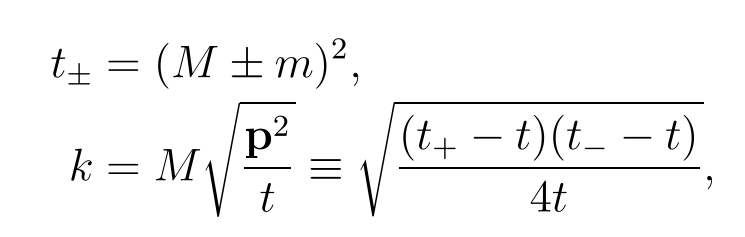

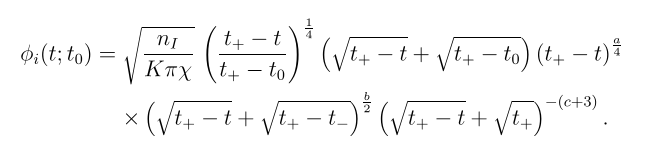

for B to K transition $n_I = 2$

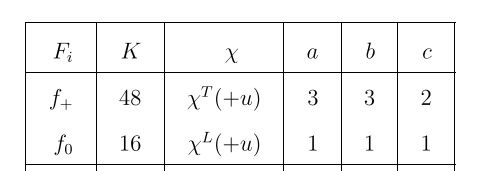

Although in [9705252] $t=q^2$ of the dilepton system, from the introduction of the subtraction point in $\chi$, q2 is really "our" Q2. Just a little ambiguity that needs some caution when at some point they use Q2=-q2

Dictionary: their $\to$ our

$t\to s=q^2$ even if initially also their $q^2$ but inconsistent (see the next)

$q^2 \to Q^2$

$Q^2 \to -Q^2$

In [ ]:
# s0 production of the quark intermediate state in the OPE (enters in the chi_OPE function)
# t+ and t- are the kinematic endpoints of the semileptonic decay, with M and m the masses of the initial and final mesons (hadronic picture)

def phi_general(s, nI, K, m, M, t0, a, b, c, Q2, s0): #[9705252]
    t_plus = (M + m)**2
    t_minus = (M - m)**2

    # internal definitions
    sqrt_s = np.sqrt(t_plus - s)
    sqrt_t0 = np.sqrt(t_plus - t0)
    sqrt_t_minus = np.sqrt(t_plus - t_minus)
    sqrt_0 = np.sqrt(t_plus)

    n_subtraction_plus1 = 3.0

    Q2_factor = ((sqrt_s + sqrt_0) / (sqrt_s + np.sqrt(t_plus - Q2)))**n_subtraction_plus1 # mind the minus sign convention in front of Q2 (in the Ref. 9705252 Q2=-q2) (see before)

    return Q2_factor * np.sqrt(nI / (K * np.pi * chi.chi_OPE(Q2, s0)[0])) * np.sqrt(sqrt_s / sqrt_t0) * (sqrt_s + sqrt_t0) * sqrt_s**(a/4.0) * (sqrt_s - sqrt_t_minus)**(b/2.0) * (sqrt_s + sqrt_0)**(-c-3.0)

In [9]:
# maybe t0=t- minimizes truncation error?

def phi_B_K(s, Q2, s0 = (chi.mb + chi.ms)**2):
    pp = eos.Parameters.Defaults()
    pp.set('mass::B_d', 5.27931)
    pp.set('mass::K_d', 0.493677)

    m = pp['mass::K_d'].evaluate()
    M = pp['mass::B_d'].evaluate()

    t_plus = (M + m)**2
    t_minus = (M - m)**2

    nI = 2.0
    K = 48.0
    a = 3.0
    b = 3.0
    c = 2.0
    return phi_general(s, nI, K, m, M, t_minus, a, b, c, Q2, s0)

In [10]:
print(phi_B_K(0, Q2 = 0.0))

0.006253624132335376
